In [ ]:
# Módulo 4 sesión 4
# Paso 1: Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from scipy.stats import shapiro

In [ ]:
# Paso 2: Crear un conjunto de datos sintéticos
np.random.seed(42)
n = 100
horas_estudio = np.random.normal(5, 2, n).clip(0)
uso_celular = np.random.normal(3, 1, n).clip(0)
nota = 1.5 * horas_estudio - 1.0 * uso_celular + np.random.normal(0, 1, n)

# Crear el DataFrame
df = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'uso_celular': uso_celular,
    'nota': nota
})
df.head()

,horas_estudio,uso_celular,nota
0,5.993428,1.584629,7.763301
1,4.723471,2.579355,5.066637
2,6.295377,2.657285,7.868831
3,8.046060,2.197723,10.925169
4,4.531693,2.838714,2.581156


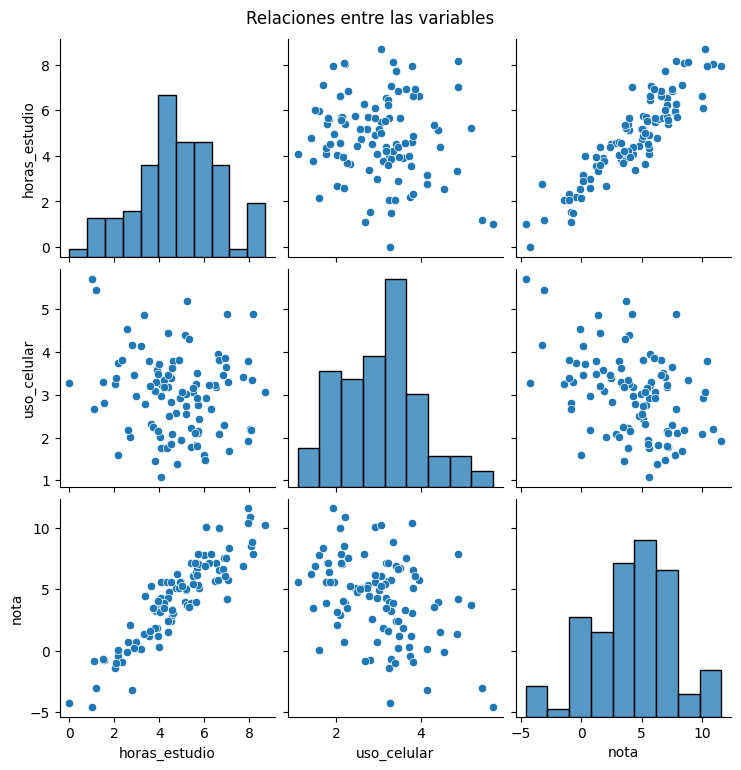

In [ ]:
# Paso 3: Visualización exploratoria
sns.pairplot(df)
plt.suptitle("Relaciones entre las variables", y=1.02)
plt.show()
# Este gráfico es una matriz de dispersión (pairplot) generada con Seaborn, y nos
# permite analizar las relaciones entre tres variables: horas_estudio, uso_celular y nota.
# 1. Diagonal Principal: Distribuciones individuales
# Los histogramas de la diagonal muestran la distribución de cada variable:

# horas_estudio: distribución más o menos simétrica.

# uso_celular: ligeramente sesgada hacia la izquierda (mayoría entre 2 y 4).

# nota: ligeramente sesgada a la derecha, con valores concentrados entre 3 y 7.
# 2. Fuera de la diagonal: Relaciones entre variables
# Estos gráficos son diagramas de dispersión (scatter plots) que muestran cómo se
# relacionan dos variables a la vez.
# La nota se ve fuertemente influenciada por las horas de estudio (positivo) y uso del celular (negativo).

# Las horas de estudio y el uso del celular parecen ser variables independientes entre sí.

In [ ]:
# Paso 4: Regresión Lineal Simple con sklearn
X_simple = df[['horas_estudio']]
y = df['nota']
modelo_simple = LinearRegression()
modelo_simple.fit(X_simple, y)
# Coeficientes
print("Intercepto (β0):", modelo_simple.intercept_)
print("Pendiente (β1):", modelo_simple.coef_[0])
# Nota estimada=-3.85+1.69*Horas de estudio
# Horas de estudio= 6 horas
# Nota estimada=-3.85+1.69*6=6,29


Intercepto (β0): -3.8489283510719847
Pendiente (β1): 1.6859385717397548


In [ ]:
# Predicciones y R²
y_pred_simple = modelo_simple.predict(X_simple)
print("R²:", r2_score(y, y_pred_simple))
# Mostrar los primeros 5 valores predichos
print("Primeros 5 valores predichos:")
print(y_pred_simple[:5])

R²: 0.8197053286484438
Primeros 5 valores predichos:
[6.25562361 4.11455427 6.76469069 9.71623407 3.7912281 ]


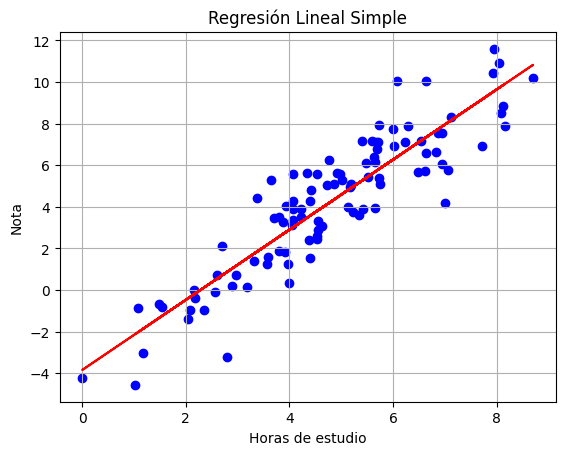

In [ ]:
# Visualización
plt.scatter(df['horas_estudio'], y, color='blue')
plt.plot(df['horas_estudio'], y_pred_simple, color='red')
plt.xlabel("Horas de estudio")
plt.ylabel("Nota")
plt.title("Regresión Lineal Simple")
plt.grid(True)
plt.show()

In [ ]:
# Paso 5: Métricas de error
mse = mean_squared_error(y, y_pred_simple)
mae = mean_absolute_error(y, y_pred_simple)
print("Error Cuadrático Medio (MSE):", mse)
print("Error Absoluto Medio (MAE):", mae)
# El MSE (Mean Squared Error) mide el promedio de los cuadrados de los errores
# (la diferencia entre los valores reales y los valores predichos por el modelo).
# MSE=2.0272 Esto significa que en promedio, el cuadrado de la diferencia entre las notas
# reales y las predichas por el modelo es 2.027.
# Cuanto menor sea este valor, mejor es el modelo.
# Valores altos indican que hay una mayor diferencia entre lo que el modelo predice
# y los datos reales.
# El MAE (Mean Absolute Error) es el promedio de los errores absolutos entre los
# valores reales y los predichos.
# MAE=1.1628 Esto indica que el modelo se equivoca, en promedio, 1.16 unidades en la predicción
# de la nota.
# Si las notas están en una escala de 0 a 10, un error promedio de 1.16 es aceptable, pero se puede mejorar.
# MAE es más intuitivo que MSE porque está en la misma escala que la variable dependiente (nota).

Error Cuadrático Medio (MSE): 2.0271972795022877
Error Absoluto Medio (MAE): 1.1628259330253312


In [ ]:
# Paso 6: Regresión Lineal Múltiple con statsmodels
X_multiple = df[['horas_estudio', 'uso_celular']]
X_multiple_const = sm.add_constant(X_multiple)
modelo_multiple = sm.OLS(y, X_multiple_const).fit()
print(modelo_multiple.summary())
# Nota estimada = B0 + B1*X1 + B2*X2
# Hipótesis nula: H0: B1=B2=0 vs Hipotesis alternativa H1: Al menos un Bi es distinto de cero (B1 es distintinto de cero o B2 es distinto de cero)
# Si el p valor es menor que 0.05 entonces se rechaza H0, p valor=0< 0,05

# H0: B0=0 vs H1: B0 es distinto de cero, p valor=0,373>0,05 entonces no rechazo H0.
# H0: B1=0 vs H1: B1 es distinto de cero, p valor=0<0,05, rechazo H0

# 1.493<B1<1,733 un intervalo del 95% de confianza, 1-alpha=1-0,05=0,95
#-1,416<B0<0,536; el intervalo contiene el cero

                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     437.7
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           2.81e-49
Time:                        12:59:20   Log-Likelihood:                -147.63
No. Observations:                 100   AIC:                             301.3
Df Residuals:                      97   BIC:                             309.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.4400      0.492     -0.895

In [ ]:
# Paso 7: Validación de supuestos

# 1. Normalidad de los residuos
# H0: Los residuos o errores del modelo siguen una dsitribución Normal
# H1: Los residuos o errores del modelo no siguen una distribución Normal
residuos = modelo_multiple.resid
stat, p = shapiro(residuos)
print("Test de Shapiro-Wilk para normalidad de errores:")
print("Estadístico:", stat, "| Valor-p:", p)
# p valor=0,48> 0,05, no rechazo H0, es decir que los residuos o errores del modelo siguen una distribución Normal
# Error= valor real de Y - valor estimado por mi modelo

Test de Shapiro-Wilk para normalidad de errores:
Estadístico: 0.98756886289493 | Valor-p: 0.4769819295558799


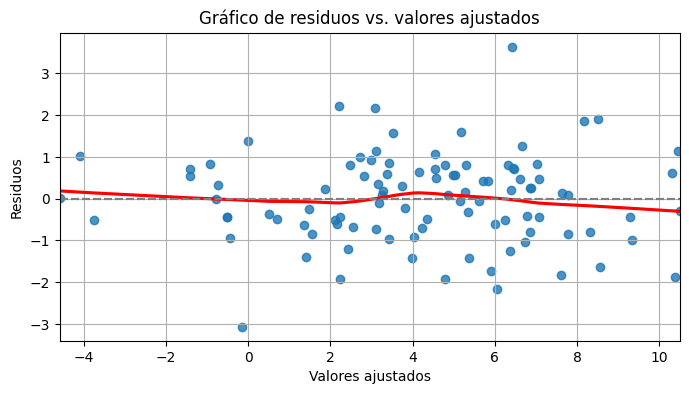

In [ ]:
# 2. Gráfico de residuos
plt.figure(figsize=(8,4))
sns.residplot(x=modelo_multiple.fittedvalues, y=residuos, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos vs. valores ajustados")
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True)
plt.show()

Queremos evaluar si el modelo cumple con una de las suposiciones clave de la regresión lineal:
“Los residuos tienen varianza constante (homocedasticidad) y no tienen patrón sistemático.”
Distribución dispersa y centrada en 0:

Los puntos están dispersos aleatoriamente alrededor de la línea horizontal en 0.

Esto sugiere que la varianza de los errores es constante (no hay heterocedasticidad).

Línea roja relativamente plana:

Indica que no hay patrones sistemáticos en los residuos (por ejemplo, curvaturas o tendencias).

Esto sugiere que la relación entre las variables puede considerarse aproximadamente lineal.

No hay forma clara de "U", "S" o embudo:

No hay indicios de que falte una variable cuadrática o de problemas de forma funcional.

In [ ]:
# Hacer predicciones con el modelo entrenado
predicciones = modelo_multiple.predict(X_multiple_const)

# Mostrar los primeros 5 valores predichos
print("Primeros 5 valores predichos:")
print(predicciones[:5])

Primeros 5 valores predichos:
0     7.623716
1     4.568160
2     7.024893
3    10.314135
4     3.996244
dtype: float64


In [ ]:
# Unir los valores originales con las predicciones
df_pred = df[['horas_estudio', 'uso_celular']].copy()
df_pred['nota_real'] = y
df_pred['nota_predicha'] = predicciones

# Mostrar las primeras 5 filas
print(df_pred.head())

   horas_estudio  uso_celular  nota_real  nota_predicha
0       5.993428     1.584629   7.763301       7.623716
1       4.723471     2.579355   5.066637       4.568160
2       6.295377     2.657285   7.868831       7.024893
3       8.046060     2.197723  10.925169      10.314135
4       4.531693     2.838714   2.581156       3.996244


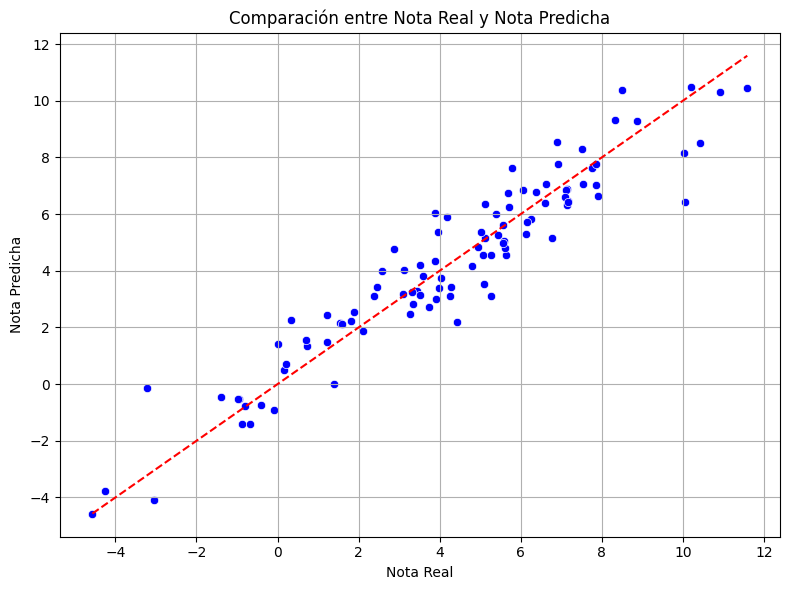

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un DataFrame con valores reales y predichos
df_pred = df[['nota']].copy()
df_pred['nota_predicha'] = predicciones

# Gráfico de dispersión real vs. predicho
plt.figure(figsize=(8, 6))
sns.scatterplot(x='nota', y='nota_predicha', data=df_pred, color='blue')
plt.plot([df['nota'].min(), df['nota'].max()], [df['nota'].min(), df['nota'].max()], 'r--')  # Línea de referencia
plt.xlabel('Nota Real')
plt.ylabel('Nota Predicha')
plt.title('Comparación entre Nota Real y Nota Predicha')
plt.grid(True)
plt.tight_layout()
plt.show()

El gráfico muestra una comparación entre las notas reales y las notas predichas por tu modelo de regresión. Cada punto azul representa una observación (un estudiante), con:

Eje X (horizontal): la nota real obtenida (observada en los datos).

Eje Y (vertical): la nota predicha por el modelo (lo que estima la regresión).

Interpretación de los elementos:
Puntos azules (observaciones individuales):
Si un punto cae sobre la línea roja discontinua, significa que el modelo predijo exactamente el valor real.

Si un punto está cerca de la línea, el error de predicción es bajo (buena predicción).

Si un punto está lejos de la línea, el modelo cometió un mayor error de predicción.

Línea roja discontinua:
Representa la línea y = x, es decir, el caso ideal donde predicción = realidad.

Sirve como referencia para comparar cuánto se desvían los puntos predichos respecto a los valores reales.

Conclusión general:
Tus puntos se alinean bastante bien a lo largo de la línea roja, lo cual indica que el modelo tiene un buen ajuste.

Hay cierta dispersión (natural en datos reales), pero no se observan patrones sistemáticos de error.

El modelo está captando correctamente la relación entre horas de estudio, uso del celular y nota.



In [ ]:
# 0. Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Cargar datos desde la web
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
print(df.head(), "\n")
print(df.info(), "\n")
print("Valores nulos por columna:\n", df.isnull().sum(), "\n")

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None 

Valores nulos por columna:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size   

In [ ]:
# 0. Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
# 2. Regresión lineal múltiple (incluye variables categóricas automáticamente)
modelo = smf.ols('tip ~ total_bill + size + sex + smoker + day + time', data=df).fit()
# tip=b0+B1*total_bill+B2*size+B3*

# 3. Resumen completo del modelo
print(modelo.summary())
# H0: B1=B2=B3=B4=B5=B6=0
# H1: Al menos un Bi distinto de cero

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     26.06
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           1.20e-28
Time:                        15:58:39   Log-Likelihood:                -347.48
No. Observations:                 244   AIC:                             713.0
Df Residuals:                     235   BIC:                             744.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.8038      0.353      2.279

In [ ]:
# 3. Calcular matriz de correlación
# 1. Seleccionar columnas numéricas
df_numeric = df.select_dtypes(include=[np.number])

# 2. Calcular matriz de correlación
correlation_matrix = df_numeric.corr()

# 3. Mostrar matriz de correlación
print("Matriz de correlación:\n", correlation_matrix)

Matriz de correlación:
             total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


Las variables categóricas se transforman automáticamente en variables dummy (0 y 1) en statsmodels cuando usas la fórmula ('tip ~ var1 + var2 + var3'). Esto es lo que permite que se incluyan variables como sex, day, time, etc.

Coeficientes: muestran el impacto esperado en la propina (tip) al aumentar en una unidad la variable (cuantitativa) o cambiar de categoría (dummy).

Ejemplo:

total_bill = 0.0945: por cada dólar adicional en la cuenta, se espera que la propina aumente $0.0945, manteniendo las demás variables constantes.

sex[T.Male] = -0.0324: los hombres tienden a dejar $0.0324 menos en propina comparado con las mujeres (aunque no es significativo).

p-valor (P>|t|): si es menor a 0.05, el efecto es estadísticamente significativo.

Aquí solo total_bill y apenas size (con p ≈ 0.051) son significativas.

R² = 0.470: el modelo explica el 47% de la variabilidad en las propinas.

ANOVA (F-statistic):

F = 26.06, Prob(F) ≈ 1.20e-28: indica que el modelo como un todo es altamente significativo.

In [ ]:
# Modelo reducido con solo variables significativas al 10%
modelo_reducido = smf.ols('tip ~ total_bill + size', data=df).fit()

# Resumen del modelo
print(modelo_reducido.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           9.67e-34
Time:                        15:59:29   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6689      0.194      3.455      0.0

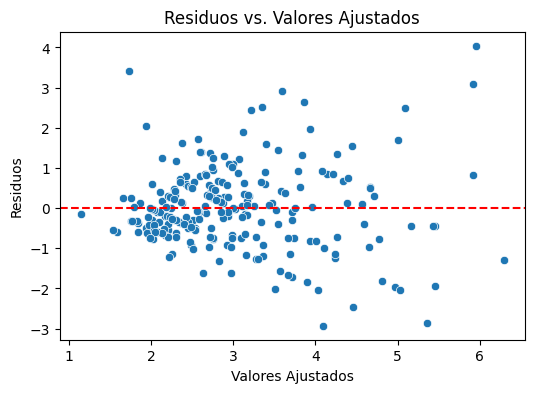

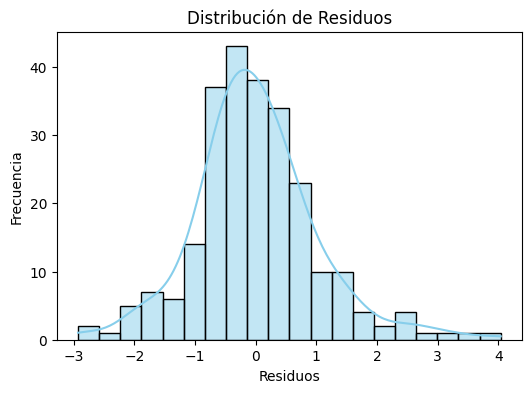

<Figure size 600x400 with 0 Axes>

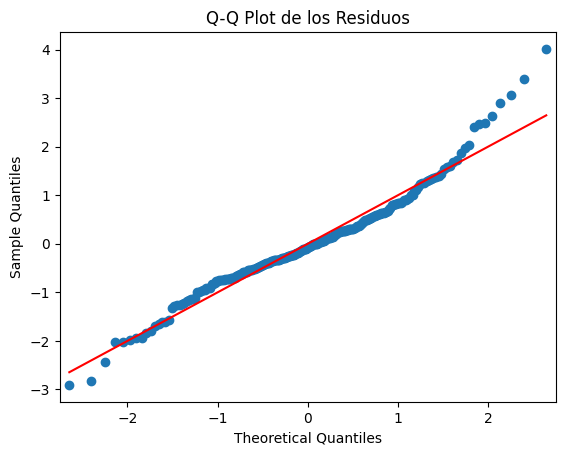

In [ ]:
import scipy.stats as stats
# 2. Obtener residuos y valores ajustados
residuos = modelo_reducido.resid
ajustados = modelo_reducido.fittedvalues

# 3. Gráfico: Residuos vs. Valores Ajustados
plt.figure(figsize=(6, 4))
sns.scatterplot(x=ajustados, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs. Valores Ajustados")
plt.show()

# 4. Histograma de residuos
plt.figure(figsize=(6, 4))
sns.histplot(residuos, kde=True, color='skyblue', bins=20)
plt.title("Distribución de Residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

# 5. Q-Q Plot (Normalidad de residuos)
plt.figure(figsize=(6, 4))
sm.qqplot(residuos, line='s', fit=True)
plt.title("Q-Q Plot de los Residuos")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from scipy.stats import shapiro
import pandas as pd # Se importa para el ejemplo de regresión múltiple con DataFrame

# --- REGRESIONES LINEALES SIMPLES ---
print("--- REGRESIÓN LINEAL SIMPLE ---")

# 1. Creación de los Datos de Ejemplo
# X es la variable independiente (ej. horas estudiadas)
# Y es la variable dependiente (ej. calificación obtenida)
X_simple = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y_simple = np.array([2, 3, 5, 6, 8])

print(f"Datos X (simple): {X_simple.flatten()}")
print(f"Datos Y (simple): {Y_simple}")



--- REGRESIÓN LINEAL SIMPLE ---
Datos X (simple): [1 2 3 4 5]
Datos Y (simple): [2 3 5 6 8]


In [ ]:
# 2. Creación y Entrenamiento del Modelo con scikit-learn
modelo_simple_sklearn = LinearRegression()
modelo_simple_sklearn.fit(X_simple, Y_simple)

# 3. Obtención de los Coeficientes de la Regresión
beta_0_sklearn = modelo_simple_sklearn.intercept_
beta_1_sklearn = modelo_simple_sklearn.coef_[0]

print(f"\nIntercepto (beta_0) (sklearn): {beta_0_sklearn}")
print(f"Pendiente (beta_1) (sklearn): {beta_1_sklearn}")
print(f"Ecuación de la regresión simple: Y = {beta_0_sklearn:.2f} + {beta_1_sklearn:.2f}X")


Intercepto (beta_0) (sklearn): 0.3000000000000007
Pendiente (beta_1) (sklearn): 1.4999999999999998
Ecuación de la regresión simple: Y = 0.30 + 1.50X


In [ ]:
# 4. Hacer Predicciones
Y_pred_simple_sklearn = modelo_simple_sklearn.predict(X_simple)
print(f"Predicciones (sklearn): {Y_pred_simple_sklearn}")

Predicciones (sklearn): [1.8 3.3 4.8 6.3 7.8]


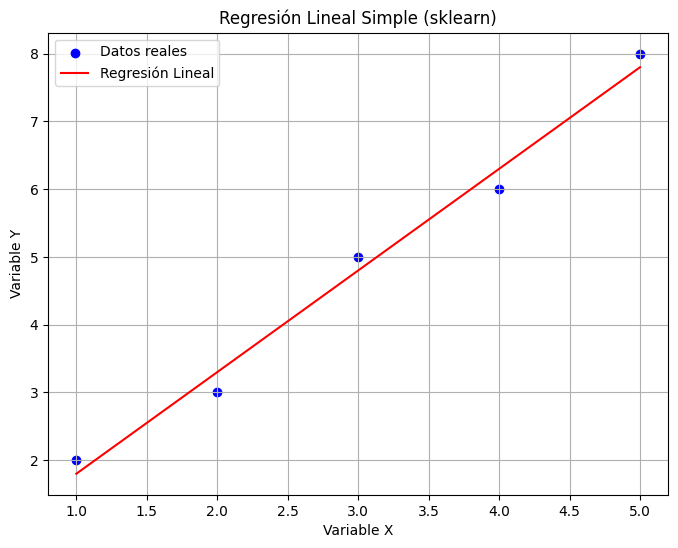

In [ ]:
# 5. Visualización de la Regresión Simple
plt.figure(figsize=(8, 6))
plt.scatter(X_simple, Y_simple, color="blue", label="Datos reales")
plt.plot(X_simple, Y_pred_simple_sklearn, color="red", label="Regresión Lineal")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.title("Regresión Lineal Simple (sklearn)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# --- MÉTRICAS DE ERROR ---
print("\n--- MÉTRICAS DE ERROR ---")

Y_real_ejemplo = np.array([2, 3, 5, 6, 8])
Y_pred_ejemplo = np.array([2.2, 3.1, 4.8, 5.9, 7.5])

# 1. Error Cuadrático Medio (MSE)
mse = mean_squared_error(Y_real_ejemplo, Y_pred_ejemplo)
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")


--- MÉTRICAS DE ERROR ---
Error Cuadrático Medio (MSE): 0.0700


In [ ]:
# 2. Error Absoluto Medio (MAE)
mae = mean_absolute_error(Y_real_ejemplo, Y_pred_ejemplo)
print(f"Error Absoluto Medio (MAE): {mae:.4f}")

Error Absoluto Medio (MAE): 0.2200


In [ ]:
# 3. Coeficiente de Determinación R2
r2 = r2_score(Y_real_ejemplo, Y_pred_ejemplo)
print(f"Coeficiente de determinación R2: {r2:.4f}")
print(f"Interpretación R2: El modelo explica el {r2*100:.2f}% de la variabilidad en Y.")

Coeficiente de determinación R2: 0.9846
Interpretación R2: El modelo explica el 98.46% de la variabilidad en Y.


In [ ]:
# --- IMPLEMENTACIÓN EN PYTHON CON LIBRERÍA STATSMODELS (Regresión Simple) ---
print("\n--- REGRESIÓN SIMPLE con STATSMODELS ---")

# Preparar X para statsmodels (añadir una columna de unos para el intercepto)
X_simple_sm = sm.add_constant(X_simple)

# Crear y ajustar el modelo OLS (Ordinary Least Squares)
modelo_simple_sm = sm.OLS(Y_simple, X_simple_sm).fit()

# Resumen del modelo
print(modelo_simple_sm.summary())
# En la salida esperada se pueden ver:
# - Coeficientes (const para beta_0, X1 para beta_1)
# - R2 y R2 ajustado
# - Errores estándar, t-values y p-values


--- REGRESIÓN SIMPLE con STATSMODELS ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     225.0
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           0.000643
Time:                        13:07:57   Log-Likelihood:              -0.061166
No. Observations:                   5   AIC:                             4.122
Df Residuals:                       3   BIC:                             3.341
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
# --- REGRESIONES LINEALES MÚLTIPLES ---
print("\n--- REGRESIÓN LINEAL MÚLTIPLE ---")

# Datos de ejemplo para regresión múltiple (ejemplo de ventas vs. publicidad)
data = {
    'Ventas': [200, 220, 250, 270, 300, 310, 330, 350, 370, 400],
    'TV': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95],
    'Radio': [10, 12, 15, 18, 20, 22, 25, 28, 30, 32],
    'Internet': [5, 6, 8, 9, 10, 11, 12, 13, 14, 15]
}
df_multiple = pd.DataFrame(data)

Y_multiple = df_multiple['Ventas'] # Variable dependiente
X_multiple = df_multiple[['TV', 'Radio', 'Internet']] # Variables independientes


--- REGRESIÓN LINEAL MÚLTIPLE ---


In [ ]:
# Añadir una columna de unos para el intercepto
X_multiple_sm = sm.add_constant(X_multiple)

# Crear y ajustar el modelo de regresión múltiple
modelo_multiple_sm = sm.OLS(Y_multiple, X_multiple_sm).fit()

# Resumen del modelo de regresión múltiple
print(modelo_multiple_sm.summary())
# En la salida esperada se pueden ver:
# - Coeficientes (beta_0, beta_1, beta_2, etc.)
# - R2 y R2 ajustado para evaluar la calidad del modelo
# - Significancia de las variables mediante p-values

                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     608.5
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           7.68e-08
Time:                        13:08:55   Log-Likelihood:                -26.824
No. Observations:                  10   AIC:                             61.65
Df Residuals:                       6   BIC:                             62.86
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6959     62.424     -0.027      0.9

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
# --- SUPUESTOS DE REGRESIÓN MÚLTIPLE Y TEST DE NORMALIDAD ---
print("\n--- TEST DE NORMALIDAD DEL ERROR (Shapiro-Wilk) ---")

# Obtener los residuos del modelo
residuos = modelo_multiple_sm.resid

# Realizar el test de Shapiro-Wilk
stat, p_value_shapiro = shapiro(residuos)

print(f"Estadístico de Shapiro-Wilk: {stat:.4f}")
print(f"P-valor del test de Shapiro-wilk: {p_value_shapiro:.4f}")
# Evaluar el resultado del test (comúnmente se usa un p-valor > 0.05 para asumir normalidad)
if p_value_shapiro > 0.05:
    print("Los residuos parecen seguir una distribución normal (no se rechaza H0).")
else:
    print("Los residuos no siguen una distribución normal (se rechaza H0).")

print("\n--- Conclusión General ---")
print("Este código demuestra la implementación de regresiones lineales (simples y múltiples),")
print("el cálculo de métricas de error (MSE, MAE, R2) y la evaluación de supuestos como la normalidad del error.")


--- TEST DE NORMALIDAD DEL ERROR (Shapiro-Wilk) ---
Estadístico de Shapiro-Wilk: 0.8958
P-valor del test de Shapiro-wilk: 0.1971
Los residuos parecen seguir una distribución normal (no se rechaza H0).

--- Conclusión General ---
Este código demuestra la implementación de regresiones lineales (simples y múltiples),
el cálculo de métricas de error (MSE, MAE, R2) y la evaluación de supuestos como la normalidad del error.
